In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# NOTE: MinMaxScaler is NOT needed for Random Forest.
# Tree-based models are scale-invariant — they split on
# thresholds, so feature magnitude doesn't matter.

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/Capstone/Project/vmCloud_data.csv'

df = pd.read_csv(DATASET_PATH)

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nColumns found: {list(df.columns)}')

Dataset loaded: 2000000 rows, 12 columns

Columns found: ['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'task_type', 'task_priority', 'task_status']


In [ ]:
df.head()

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting


In [ ]:
df.dtypes

,0
vm_id,object
timestamp,object
cpu_usage,float64
memory_usage,float64
network_traffic,float64
power_consumption,float64
num_executed_instructions,float64
execution_time,float64
energy_efficiency,float64
task_type,object


In [ ]:
df.describe().round(3)

,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency
count,1800962.000,1799490.000,1800519.000,1799729.000,1800314.000,1800173.000,1799958.000
mean,50.012,49.982,500.008,250.058,5001.897,49.971,0.500
std,28.877,28.853,288.579,144.363,2885.247,28.861,0.289
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,24.977,25.004,250.067,124.970,2504.000,24.979,0.250
50%,50.055,49.976,500.008,250.247,5002.000,49.964,0.500
75%,75.029,74.956,749.817,375.107,7502.000,74.977,0.750
max,100.000,100.000,1000.000,499.999,9999.000,100.000,1.000


In [ ]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print('No missing values found!')
else:
    print('Missing values detected:')
    print(missing_report)

Missing values detected:
                           Missing Count  Missing %
vm_id                             200638      10.03
timestamp                         200666      10.03
cpu_usage                         199038       9.95
memory_usage                      200510      10.03
network_traffic                   199481       9.97
power_consumption                 200271      10.01
num_executed_instructions         199686       9.98
execution_time                    199827       9.99
energy_efficiency                 200042      10.00
task_type                         199962      10.00
task_priority                     199433       9.97
task_status                       200306      10.02


In [ ]:
# Fill missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  → {col}: filled with median ({df[col].median():.3f})')

# Categorical columns: fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  → {col}: filled with mode ({df[col].mode()[0]})')

print(f'\n Missing values handled. Remaining nulls: {df.isnull().sum().sum()}')


 Missing values handled. Remaining nulls: 0


In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)
print(f'Rows before: {before}')
print(f'Rows after:  {after}')
print(f'Duplicates removed: {before - after}')

Rows before: 2000000
Rows after:  2000000
Duplicates removed: 0


In [ ]:
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Sort for lag/rolling features to be meaningful
    df.sort_values('timestamp', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Extract time features — RF treats these as regular numeric features
    df['hour']       = df['timestamp'].dt.hour
    df['dayofweek']  = df['timestamp'].dt.dayofweek
    df['dayofmonth'] = df['timestamp'].dt.day
    df['month']      = df['timestamp'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    df.drop(columns=['timestamp'], inplace=True)
    print(' Timestamp parsed. Extracted: hour, dayofweek, dayofmonth, month, is_weekend')
else:
    print(' No timestamp column found — skipping.')+

 Timestamp parsed. Extracted: hour, dayofweek, dayofmonth, month, is_weekend


In [ ]:
if 'vm_id' in df.columns:
    unique_vms = df['vm_id'].nunique()
    print(f'   Unique VMs found: {unique_vms}')

    # Option A: Drop it (if it's just a label with no ordinal meaning)
    df.drop(columns=['vm_id'], inplace=True)
    print(' vm_id dropped (identifier — not useful as an ML feature)')

else:
    print(' No vm_id column found — skipping.')

   Unique VMs found: 1799362
 vm_id dropped (identifier — not useful as an ML feature)


In [ ]:
CATEGORICAL_COLS = ['task_type', 'task_priority', 'task_status']
cols_to_encode   = [c for c in CATEGORICAL_COLS if c in df.columns]

label_encoders = {}

for col in cols_to_encode:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col]  = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  → {col}: {mapping}')

df.drop(columns=cols_to_encode, inplace=True)
print(f'\n Encoding done! Encoded columns: {[c+"_encoded" for c in cols_to_encode]}')

  → task_type: {'compute': np.int64(0), 'io': np.int64(1), 'network': np.int64(2)}
  → task_priority: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
  → task_status: {'completed': np.int64(0), 'running': np.int64(1), 'waiting': np.int64(2)}

 Encoding done! Encoded columns: ['task_type_encoded', 'task_priority_encoded', 'task_status_encoded']


In [ ]:
# Drop any remaining object columns
remaining_objects = df.select_dtypes(include=['object']).columns.tolist()
if remaining_objects:
    print(f' Still have object columns: {remaining_objects} → dropping.')
    df.drop(columns=remaining_objects, inplace=True)
else:
    print(' All columns are numeric!')

 All columns are numeric!


In [ ]:
# Confirm no more object columns remain
remaining_objects = df.select_dtypes(include=['object']).columns.tolist()
if remaining_objects:
    print(f' Still have object columns: {remaining_objects}')
    print('   → Drop them or handle them manually.')
    df.drop(columns=remaining_objects, inplace=True)
    print('   → Dropped automatically.')
else:
    print(' All columns are now numeric!')

 All columns are now numeric!


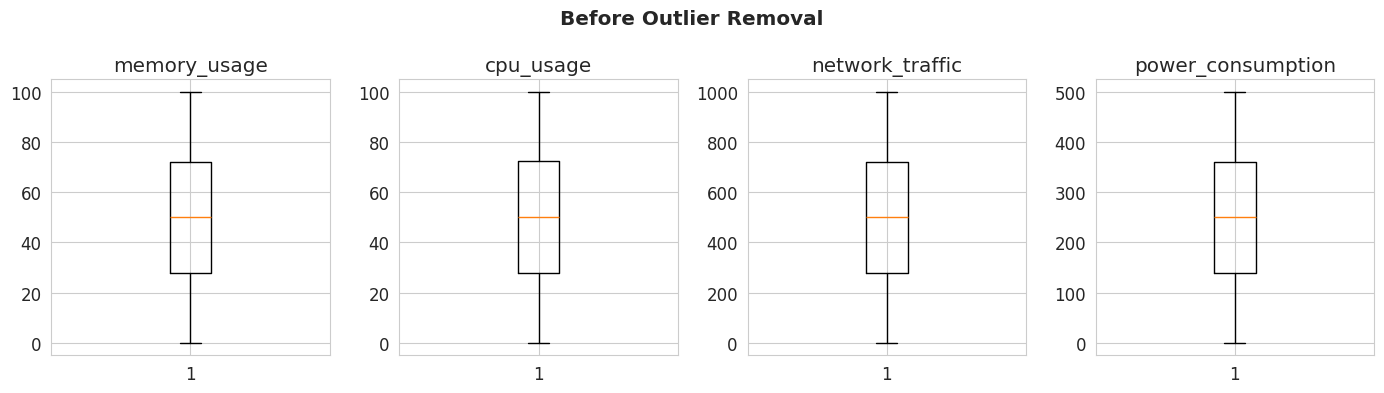

In [ ]:
# Visualize before outlier removal
key_cols = [c for c in ['memory_usage', 'cpu_usage', 'network_traffic', 'power_consumption'] if c in df.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(14, 4))
if len(key_cols) == 1:
    axes = [axes]
for i, col in enumerate(key_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Before Outlier Removal', fontweight='bold')
plt.tight_layout()
# plt.savefig('boxplot_before.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
def remove_outliers_iqr(dataframe, columns, threshold=1.5):
    df_clean = dataframe.copy()
    total_removed = 0
    for col in columns:
        if col not in df_clean.columns:
            continue
        Q1  = df_clean[col].quantile(0.25)
        Q3  = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower  = Q1 - threshold * IQR
        upper  = Q3 + threshold * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed = before - len(df_clean)
        total_removed += removed
        print(f'  {col}: {removed} outliers removed')
    print(f'\nTotal removed: {total_removed} | Remaining rows: {len(df_clean)}')
    return df_clean

outlier_cols = [c for c in ['memory_usage', 'cpu_usage', 'network_traffic',
                             'power_consumption', 'execution_time'] if c in df.columns]
df = remove_outliers_iqr(df, outlier_cols)
df.reset_index(drop=True, inplace=True)
print(' Outlier removal done!')

  memory_usage: 0 outliers removed
  cpu_usage: 0 outliers removed
  network_traffic: 0 outliers removed
  power_consumption: 0 outliers removed
  execution_time: 0 outliers removed

Total removed: 0 | Remaining rows: 2000000
 Outlier removal done!


In [ ]:
# Rolling window features
if 'memory_usage' in df.columns:
    df['memory_roll_mean_5']  = df['memory_usage'].rolling(5,  min_periods=1).mean()
    df['memory_roll_mean_10'] = df['memory_usage'].rolling(10, min_periods=1).mean()
    df['memory_roll_std_5']   = df['memory_usage'].rolling(5,  min_periods=1).std().fillna(0)
    df['memory_roll_max_5']   = df['memory_usage'].rolling(5,  min_periods=1).max()

if 'cpu_usage' in df.columns:
    df['cpu_roll_mean_5'] = df['cpu_usage'].rolling(5, min_periods=1).mean()
    df['cpu_roll_std_5']  = df['cpu_usage'].rolling(5, min_periods=1).std().fillna(0)

print(' Rolling features created')

 Rolling features created


In [ ]:
# Lag features
if 'memory_usage' in df.columns:
    for lag in [1, 2, 3, 5]:
        df[f'memory_lag_{lag}'] = df['memory_usage'].shift(lag)

if 'cpu_usage' in df.columns:
    for lag in [1, 2, 3]:
        df[f'cpu_lag_{lag}'] = df['cpu_usage'].shift(lag)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(' Lag features created')

 Lag features created


In [ ]:
# Rate-of-change & interaction features
if 'memory_usage' in df.columns:
    df['memory_rate_of_change'] = df['memory_usage'].diff().fillna(0)
    df['memory_pct_change']     = df['memory_usage'].pct_change().fillna(0).replace([np.inf, -np.inf], 0)

if 'cpu_usage' in df.columns:
    df['cpu_rate_of_change'] = df['cpu_usage'].diff().fillna(0)

if 'memory_usage' in df.columns and 'cpu_usage' in df.columns:
    df['memory_cpu_product'] = df['memory_usage'] * df['cpu_usage']
    df['memory_cpu_ratio']   = df['memory_usage'] / (df['cpu_usage'] + 1e-6)

print(f' Rate-of-change & interaction features created')
print(f'   Total features now: {df.shape[1]}')

 Rate-of-change & interaction features created
   Total features now: 33


In [ ]:
df.shape

(1999995, 33)

Spike threshold (80th percentile) : 77.7082
Normal (0) : 1599996 rows  (80.0%)
Spike  (1) : 399999 rows  (20.0%)


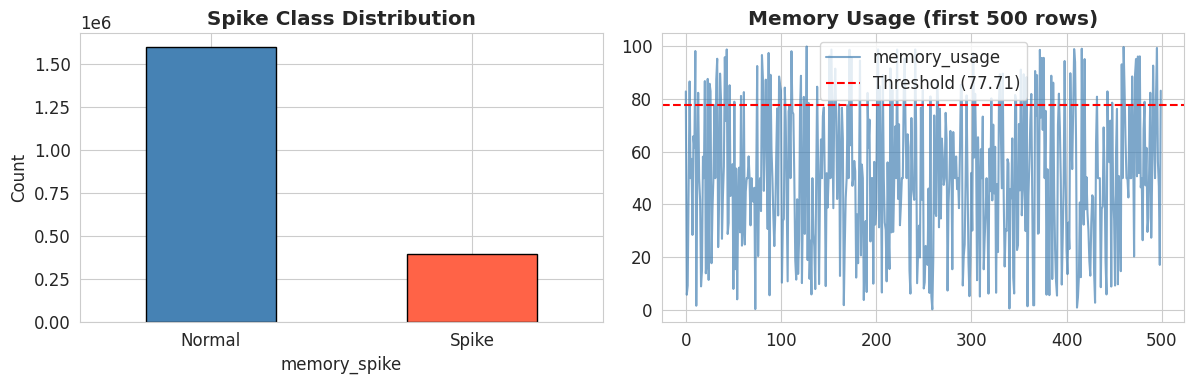

 Target variable created!


In [ ]:
SPIKE_THRESHOLD = df['memory_usage'].quantile(0.80)
df['memory_spike'] = (df['memory_usage'] > SPIKE_THRESHOLD).astype(int)

counts = df['memory_spike'].value_counts()
print(f'Spike threshold (80th percentile) : {SPIKE_THRESHOLD:.4f}')
print(f'Normal (0) : {counts.get(0,0)} rows  ({counts.get(0,0)/len(df)*100:.1f}%)')
print(f'Spike  (1) : {counts.get(1,0)} rows  ({counts.get(1,0)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Spike Class Distribution', fontweight='bold')
axes[0].set_xticklabels(['Normal', 'Spike'], rotation=0)
axes[0].set_ylabel('Count')

sample = df['memory_usage'].iloc[:500]
sample.plot(ax=axes[1], color='steelblue', alpha=0.7)
axes[1].axhline(SPIKE_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({SPIKE_THRESHOLD:.2f})')
axes[1].set_title('Memory Usage (first 500 rows)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
# plt.savefig('memory_spike_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Target variable created!')

In [ ]:
TARGET_COL   = 'memory_spike'

EXCLUDE_COLS = ['memory_spike', 'memory_usage']   # exclude both from features

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feature_cols].values   # shape: (samples, features)  ← 2D, RF-ready
y = df[TARGET_COL].values     # shape: (samples,)

print(f' Feature matrix X shape : {X.shape}  →  (samples, features)')
print(f'   Target vector  y shape : {y.shape}')
print(f'\n   Feature list ({len(feature_cols)} features):')
for i, f in enumerate(feature_cols, 1):
    print(f'    {i:2d}. {f}')

 Feature matrix X shape : (1999995, 32)  →  (samples, features)
   Target vector  y shape : (1999995,)

   Feature list (32 features):
     1. cpu_usage
     2. network_traffic
     3. power_consumption
     4. num_executed_instructions
     5. execution_time
     6. energy_efficiency
     7. hour
     8. dayofweek
     9. dayofmonth
    10. month
    11. is_weekend
    12. task_type_encoded
    13. task_priority_encoded
    14. task_status_encoded
    15. memory_roll_mean_5
    16. memory_roll_mean_10
    17. memory_roll_std_5
    18. memory_roll_max_5
    19. cpu_roll_mean_5
    20. cpu_roll_std_5
    21. memory_lag_1
    22. memory_lag_2
    23. memory_lag_3
    24. memory_lag_5
    25. cpu_lag_1
    26. cpu_lag_2
    27. cpu_lag_3
    28. memory_rate_of_change
    29. memory_pct_change
    30. cpu_rate_of_change
    31. memory_cpu_product
    32. memory_cpu_ratio


In [ ]:
# Step 1: Split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Step 2: Split remaining into train (70%) and val (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=y_temp
)

print(' Split Summary (shuffled + stratified — RF-appropriate):')
print(f'   Train      : {X_train.shape[0]} samples   ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'   Validation : {X_val.shape[0]} samples   ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'   Test       : {X_test.shape[0]} samples   ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\n   RF input shape  → {X_train.shape}  (2D — no sequences needed!)')

 Split Summary (shuffled + stratified — RF-appropriate):
   Train      : 1399995 samples   (70.0%)
   Validation : 300000 samples   (15.0%)
   Test       : 300000 samples   (15.0%)

   RF input shape  → (1399995, 32)  (2D — no sequences needed!)


In [ ]:
import os, pickle

project_folder = os.path.dirname(DATASET_PATH)

# Save 2D numpy arrays — RF-ready (no window dimension)
np.save(os.path.join(project_folder, 'X_train_rf.npy'), X_train)
np.save(os.path.join(project_folder, 'X_val_rf.npy'),   X_val)
np.save(os.path.join(project_folder, 'X_test_rf.npy'),  X_test)
np.save(os.path.join(project_folder, 'y_train_rf.npy'), y_train)
np.save(os.path.join(project_folder, 'y_val_rf.npy'),   y_val)
np.save(os.path.join(project_folder, 'y_test_rf.npy'),  y_test)

# Save feature list (important for inference later)
with open(os.path.join(project_folder, 'feature_cols_rf.pkl'), 'wb') as f:
    pickle.dump(feature_cols, f)

# Save label encoders
with open(os.path.join(project_folder, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(label_encoders, f)

# Save processed DataFrame
df.to_csv(os.path.join(project_folder, 'preprocessed_data_rf.csv'), index=False)

print(' All RF outputs saved!')
print(f'   X shapes → Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'   Files saved to: {project_folder}')
print(f'\n NOTE: No scaler saved — Random Forest does not require feature scaling!')

 All RF outputs saved!
   X shapes → Train: (1399995, 32), Val: (300000, 32), Test: (300000, 32)
   Files saved to: /content/drive/MyDrive/Capstone/Project

 NOTE: No scaler saved — Random Forest does not require feature scaling!
